In [4]:
# import the data itself
import pandas as pd
import numpy as np
import seaborn as sns
import pyarrow
import matplotlib.pyplot as plt
import os
import pickle
from datetime import datetime

'''
# What is needed:
   Input: 
     tag which matches name of running file (up to the first underscore '_'): A0, A1, etc...
     name of input *.parquet file
   Output:
     make output director
     hard link the input parquet file into that directory
     save output images to that directory
     save output pickled trained models to that directory
'''

unlink = False

# input
tag = "A3"
FRACTION=.1
in_parquet_name = 'out_matchjet/hadd_all'
MIN_T = 10 # GeV/c
MIN_Reco = 40 # GeV/c
MAX_T = 1000 # GeV/c
MAX_Reco = 1000 # GeV/c
SEED = 1
SIG_FLUCT=6.7




def set_keys(df):
    keys = [c for c in df.columns if 'reco' in c]
    #keys.remove('reco_phi')
    #keys.remove('reco_eta')
    #keys.append('rho_bkg_est')
    keys = ['reco_pt','reco_area','rho_bkg_est']
    print(' -- KEYS -- ', keys)
    return keys

def get_df():
    try:
        df = pd.read_parquet(in_parquet_name)
    except:
        exit(f'fatal error: failed to read {in_parquet_name}')
    
    #df = df[ (df['reco_ptlessarea'] > 15.) & (df['reco_pt'] < 100)]
    #df = df[df['reco_pt'] < 30]
    df = df.sample(frac=FRACTION, random_state=SEED)
    print(df.describe())
    return df
tagplot = r'$(p_\mathrm{T}^\mathrm{reco}-\rho\times{}A_\mathrm{jet})>15 \mathrm{GeV}/c\;\;p_\mathrm{T}^\mathrm{reco}<100\;\mathrm{GeV}/c$'

if os.path.isfile(f'{tag}/RFTree.pkl') and unlink:
    os.unlink(f'{tag}/RFTree.pkl')

if not in_parquet_name.endswith('.parquet'):
    in_parquet_name += '.parquet'

if not os.path.isfile(in_parquet_name):
    exit(f'fatal error, cannot find {in_parquet_name}')


# make output space
if not os.path.isdir(tag):
    os.mkdir(tag)
    os.link(in_parquet_name, f'{tag}/indata.parquet')

# cut down the df
df = get_df()
keys = set_keys(df)

X = df[keys]
y = df['pyth_pt']

from sklearn.model_selection import train_test_split
from sklearn import metrics
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

b_print = False
if b_print:
    print(X)
    print(y)

         rho_bkg_est        pyth_pt       pyth_phi       pyth_eta  \
count  138573.000000  138573.000000  138573.000000  138573.000000   
mean       88.718109      39.898205       3.145041      -0.000545   
std         3.747461      18.357470       1.813543       0.329840   
min        73.804253      10.000164       0.000015      -0.699976   
25%        86.156715      23.539516       1.574123      -0.251987   
50%        88.641953      40.241604       3.147371       0.000695   
75%        91.188278      55.763432       4.717847       0.250551   
max       109.332985      81.315475       6.283127       0.699969   

         pyth_charge   pyth_nconsts        reco_pt       reco_phi  \
count  138573.000000  138573.000000  138573.000000  138573.000000   
mean        0.225989      10.377079      83.085350       3.144409   
std         1.230162       4.245373      19.780245       1.813586   
min        -7.000000       1.000000       5.042204       0.000153   
25%        -1.000000       7.0000

In [ ]:
class rmse_cut:
 
    def __init__(self, val=SIG_FLUCT):
        self.sigma = val   
        self.sigma
    def add_data(self, test, pred):
        sig2_L = test[(test>(10+2*self.sigma)) & (test<(70-2*self.sigma))]
        sig2_R = test[(test<(70-2*self.sigma)) & (test>(10+2*self.sigma))]
        sig3_L = test[(test>(10+3*self.sigma)) & (test>(10+3*self.sigma))]
        sig3_R = test[(test<(70-3*self.sigma)) & (test>(10+3*self.sigma))]

        sig2_map = test[(test>sig2_L) & (test<sig2_R)]
        cut_2sig = (test > sig2_L) & (test < sig2_R);
        cut_3sig = (test > sig3_L) & (test < sig3_R);

        self.y_test_2s = test[cut_2sig]
        self.y_test_3s = test[cut_3sig]

        self.y_pred_2s = pred[cut_2sig]
        self.y_pred_3s = pred[cut_3sig]

        self.rmse_test_2s = metrics.root_mean_squared_error(self.y_test_2s, self.y_pred_2s)
        self.rmse_test_3s = metrics.root_mean_squared_error(self.y_test_3s, self.y_pred_3s)

        
        
        

In [18]:
# check for existents of tree:
if os.path.isfile(f'{tag}/RFTree.pkl'):
    with open(f'{tag}/RFTree.pkl', 'rb') as f:
        model = pickle.load(f)
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn import tree
    model = RandomForestRegressor(n_jobs=15)
    model.fit(X_train, y_train)
    pickle.dump(model, open(f'{tag}/RFTree.pkl', 'wb'))

# Predict the test set labels 'y_pred'
y_pred = model.predict(X_test)
# Evaluate the test set RMSE
rmse_test = MSE(y_test, y_pred)**(1/2)
rmse_data = MSE(df['pyth_pt'], df['reco_ptlessarea'])**(1/2)

# find the 2 sigma result
#X_2sigma = X_train[X_train>

# Print the test set RMSE
print('Test set RMSE of rf: {:.2f}'.format(rmse_test))



Test set RMSE of rf: 5.95


In [19]:
print(len(y_test))
print(len(y_test_2s))
print(len(y_test_3s))
print(y_pred)

41572
21292
12675
[20.52908592 23.95473503 16.12260569 ... 15.90724216 23.49453182
 46.95127628]


In [4]:
# print a histogram of pT - rho X area
#print(df.columns)
class DeltaPtHg:
    def __init__(self, data): 
        bins = np.linspace(-39, 39, num=40)
        bin_cnt, edges = np.histogram(data, bins=bins)
        self.y = bin_cnt / sum(bin_cnt) / (bins[1]-bins[0])
        self.x = 0.5*(edges[:-1]+edges[1:])
        
class PtHg:
    def __init__(self, data): 
        bins = np.linspace(0, 80, num=80)
        bin_cnt, edges = np.histogram(data, bins=bins)
        self.y = bin_cnt / sum(bin_cnt) / (bins[1]-bins[0])
        self.x = 0.5*(edges[:-1]+edges[1:])


if False:
    hgram = DeltaPtHg(df.reco_ptlessarea-df.pyth_pt)
    print(f'x_hits: {hgram.x}')
    print(f'bins: {hgram.y}')
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=hgram.x, y=hgram.y)
    plt.xlabel(r"$p_\mathrm{T}^\mathrm{reco}\times\rho{}A-p_\mathrm{T}^\mathrm{pyth}$")
    plt.ylabel('probability density') 


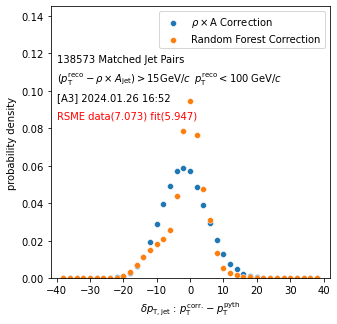

In [5]:
# Plot the comparison of the rhoXA results and the random forect predicted results
rhoA_values = DeltaPtHg(df.reco_ptlessarea-df.pyth_pt)
tree_results = DeltaPtHg(y_pred-y_test)

plt.figure(figsize=(5,5))
plt.xlabel(r"$\delta p_\mathrm{T,jet}$ : $p_\mathrm{T}^\mathrm{corr.}-p_\mathrm{T}^\mathrm{pyth}$")
plt.ylabel('probability density') 
plt.ylim((0., 0.145))
scatterplot = sns.scatterplot(x=rhoA_values.x, y=rhoA_values.y, label=r'$\rho\times$A Correction')
sns.scatterplot(x=tree_results.x,y=tree_results.y, label='Random Forest Correction')
plt.text(-40, 0.115, f'{len(df.pyth_pt)} Matched Jet Pairs')
plt.text(-40, 0.105,  tagplot)
now = datetime.now()
plt.text(-40, 0.095, f'[{tag}] {now.strftime("%Y.%m.%d %H:%M")}')
plt.text(-40, 0.085, f'RSME data({rmse_data:.3f}) fit({rmse_test:.3f})',color='red')

scatterplot.get_figure().savefig(f'{tag}/delta_pt.pdf')
scatterplot.get_figure().savefig(f'{tag}/delta_pt.svg')

plt.show()

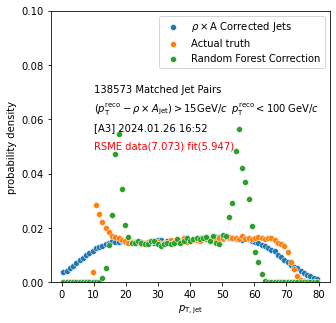

In [6]:
# looking for feature importances (Gini index); see https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html for example

# Plot the comparison of the rhoXA results and the random forect predicted results
predpt = PtHg(y_pred)
testpt = PtHg(df.pyth_pt)
rhoapt = PtHg(df.reco_ptlessarea)

plt.figure(figsize=(5,5))
plt.xlabel(r"$p_\mathrm{T,jet}$")
plt.ylabel('probability density') 
ylim_max = 0.1
plt.ylim((0., ylim_max))
scatterplot = sns.scatterplot(x=rhoapt.x, y=rhoapt.y, label=r'$\rho\times$A Corrected Jets')
sns.scatterplot(x=testpt.x,y=testpt.y, label='Actual truth')
sns.scatterplot(x=predpt.x,y=predpt.y, label='Random Forest Correction')
xlab = 10
ytop = ylim_max*0.7
ydrop = ylim_max*0.07
plt.text(xlab, ytop-ydrop*0, f'{len(df.pyth_pt)} Matched Jet Pairs')
plt.text(xlab, ytop-ydrop*1, tagplot)
plt.text(xlab, ytop-ydrop*3, f'RSME data({rmse_data:.3f}) fit({rmse_test:.3f})',color='red')
now = datetime.now()
plt.text(xlab, ytop-ydrop*2, f'[{tag}] {now.strftime("%Y.%m.%d %H:%M")}')

scatterplot.get_figure().savefig(f'{tag}/pt_dist.pdf')
scatterplot.get_figure().savefig(f'{tag}/pt_dist.svg')

plt.show()

[0.8702226  0.02294339 0.106834  ]
3


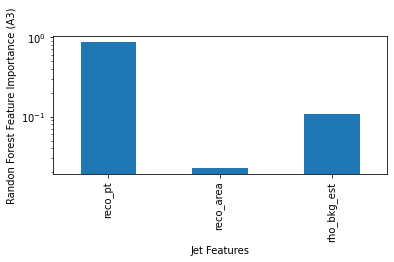

In [7]:
# looking for feature importances (Gini index); see https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html for example

importances = model.feature_importances_
print(importances)
print(len(importances))

pd_importances = pd.Series(importances, X.columns)
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.4)
plt.yscale("log")
plt.xlabel("Jet Features")
plt.ylabel(f"Randon Forest Feature Importance ({tag})")
pd_importances.plot.bar(ax=ax)
plt.savefig(f"{tag}/feature_signif.pdf", format="pdf")
plt.savefig(f"{tag}/feature_signif.svg", format="svg")
